In [8]:
import os
import sys
sys.path.append(os.getcwd())

import hydra
from hydra import compose, initialize
from omegaconf import DictConfig
import torch
import nibabel as nib
import numpy as np
from matplotlib import pyplot as plt

from dataset.dataloader import get_loader

initialize(version_base=None, config_path="config")

# Load config
cfg = compose(config_name="base_cfg")


ValueError: GlobalHydra is already initialized, call GlobalHydra.instance().clear() if you want to re-initialize

train len 2028


/home/rpinise1/.conda/envs/synth-env/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)
/home/rpinise1/.conda/envs/synth-env/lib/python3.10/site-packages/monai/data/meta_tensor.py:154: UserWarning: Setting affine, but the applied meta contains an affine. This will be overwritten.
  warnings.warn("Setting affine, but the applied meta contains an affine. This will be overwritten.")
/home/rpinise1/.conda/envs/synth-env/lib/python3.10/site-packages/monai/data/meta_tensor.py:154: UserWarning: Setting affine, but the applied meta

Extracted batch with keys: ['bdmap_id', 'organ', 'diameter_x_mm', 'diameter_y_mm', 'diameter_z_mm', 'mean_x_mm', 'mean_y_mm', 'mean_z_mm', 'std_x_mm', 'std_y_mm', 'std_z_mm', 'volume_ml', 'image', 'tumor_mask', 'organ_mask', 'tumor_mask_meta_dict', 'organ_mask_meta_dict', 'heatmap']
(96, 96, 96)
(96, 96, 96)
HEATMAP: (1, 96, 96, 96)


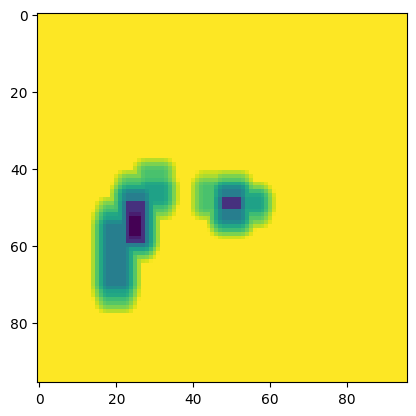

In [11]:

# 1. Initialize dataloader
train_dataloader, _, _ = get_loader(cfg.dataset)

# 2. Grab exactly one batch to inspect
batch = next(iter(train_dataloader))

# 3. Create an output directory
out_dir = "debug_vis"
os.makedirs(out_dir, exist_ok=True)

print(f"Extracted batch with keys: {list(batch.keys())}")

# 4. Extract the first sample in the batch (Index 0)
# Shape transitions from [B, C, X, Y, Z] -> [C, X, Y, Z]
tumor_tsdf = batch["tumor_mask"][0].numpy()
organ_tsdf = batch["organ_mask"][0].numpy()
coords = batch["heatmap"][0].numpy()

# 5. Squeeze the single channel dimension for the masks 
# Nibabel expects pure spatial dimensions (X, Y, Z) for 3D volumes
tumor_tsdf_3d = np.squeeze(tumor_tsdf, axis=0)
organ_tsdf_3d = np.squeeze(organ_tsdf, axis=0)
print(tumor_tsdf_3d.shape)
print(organ_tsdf_3d.shape)
print(f"HEATMAP: {coords.shape}")
plt.imshow(tumor_tsdf_3d[44])

In [14]:
organ_tsdf_3d.min()

np.float32(0.2)

train len 2028


/home/rpinise1/.conda/envs/synth-env/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)
/home/rpinise1/.conda/envs/synth-env/lib/python3.10/site-packages/monai/data/meta_tensor.py:154: UserWarning: Setting affine, but the applied meta contains an affine. This will be overwritten.
  warnings.warn("Setting affine, but the applied meta contains an affine. This will be overwritten.")
/home/rpinise1/.conda/envs/synth-env/lib/python3.10/site-packages/monai/data/meta_tensor.py:154: UserWarning: Setting affine, but the applied meta

Extracted batch with keys: ['bdmap_id', 'organ', 'diameter_x_mm', 'diameter_y_mm', 'diameter_z_mm', 'mean_x_mm', 'mean_y_mm', 'mean_z_mm', 'std_x_mm', 'std_y_mm', 'std_z_mm', 'volume_ml', 'image', 'tumor_mask', 'organ_mask', 'tumor_mask_meta_dict', 'organ_mask_meta_dict', 'heatmap']
(96, 96, 96)
(96, 96, 96)
HEATMAP: (1, 96, 96, 96)


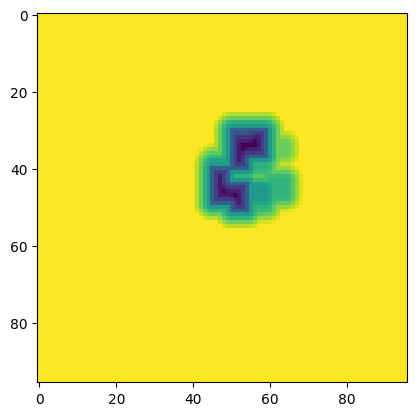

In [10]:
reconstruct(cfg)